# Phase 1 — Exploratory Data Analysis

Three questions, each tied to a later modeling decision:

1. **Class balance** — how often do home win / draw / away win occur? This sets the floor every model must beat (Phase 3 baselines, Phase 4 model).
2. **Stationarity** — have draw rates, scoring rates, and home advantage drifted across eras? This justifies (or refutes) training on a recent window only.
3. **Entity consistency** — dissolved/renamed nations (USSR, Yugoslavia, ...) create Elo discontinuities. Audit before computing Elo in Phase 2.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.config import DATA_RAW

sns.set_theme(style="whitegrid")

raw = pd.read_csv(DATA_RAW / "results.csv", parse_dates=["date"])

# Explicitly exclude unplayed fixtures (the pre-loaded WC2026 schedule).
df = raw.dropna(subset=["home_score", "away_score"]).copy()
assert (df["date"] <= pd.Timestamp.now()).all(), "played match dated in the future?"

df["goal_diff"] = df["home_score"] - df["away_score"]
df["outcome"] = pd.cut(df["goal_diff"], [-100, -0.5, 0.5, 100],
                        labels=["away_win", "draw", "home_win"])
df["year"] = df["date"].dt.year
df["decade"] = df["year"] // 10 * 10
df["total_goals"] = df["home_score"] + df["away_score"]

print(f"{len(raw):,} rows -> {len(df):,} played matches "
      f"({df['date'].min().date()} to {df['date'].max().date()})")

49,450 rows -> 49,378 played matches (1872-11-30 to 2026-06-08)


## 1. Class balance — and why `neutral` matters

Naively, "home team wins ~49% of the time." But many internationals (all World Cup matches, for instance) are at **neutral venues** where "home" is just a row label. So we split by the `neutral` flag: non-neutral matches measure *true* home advantage; neutral matches are the control.

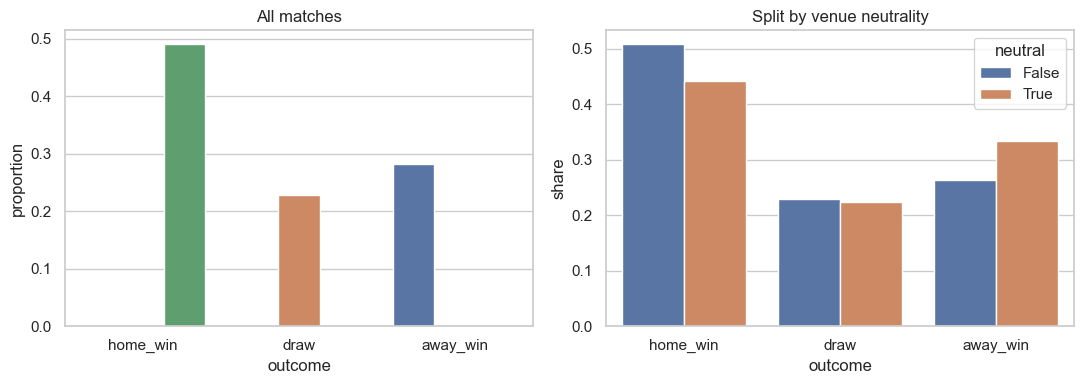

outcome  away_win   draw  home_win
neutral                           
False       0.264  0.228     0.507
True        0.334  0.224     0.442


In [2]:
dist = (df.groupby("neutral", observed=True)["outcome"]
          .value_counts(normalize=True).rename("share").reset_index())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
overall = df["outcome"].value_counts(normalize=True).reset_index()
sns.barplot(overall, x="outcome", y="proportion", hue="outcome",
            order=["home_win", "draw", "away_win"], ax=axes[0], legend=False)
axes[0].set_title("All matches")
sns.barplot(dist, x="outcome", y="share", hue="neutral",
            order=["home_win", "draw", "away_win"], ax=axes[1])
axes[1].set_title("Split by venue neutrality")
plt.tight_layout()
plt.show()

print(dist.pivot(index="neutral", columns="outcome", values="share").round(3))

**Findings:**
- Overall: home win 49.0%, away win 28.3%, draw 22.7%. The majority-class baseline ("always predict home win") scores 49% accuracy — the floor.
- True (non-neutral) home advantage: 50.7% home wins vs 26.4% away wins — a large, real effect.
- **Surprise:** even at *neutral* venues the "home" team wins 44.2% vs 33.4%. The label isn't randomly assigned at neutral venues (tournament seeding, fixture conventions), so the home/away columns carry information beyond venue. The model must encode venue effects explicitly (host nation, neutrality) rather than trusting the home label.

## 2. Non-stationarity — is old football the same game?

If base rates drift over decades, a model trained on all of history learns a blend of eras that no longer exists. We plot per-decade: goals per game, draw rate, and home win rate (non-neutral only, so home advantage is measured cleanly).

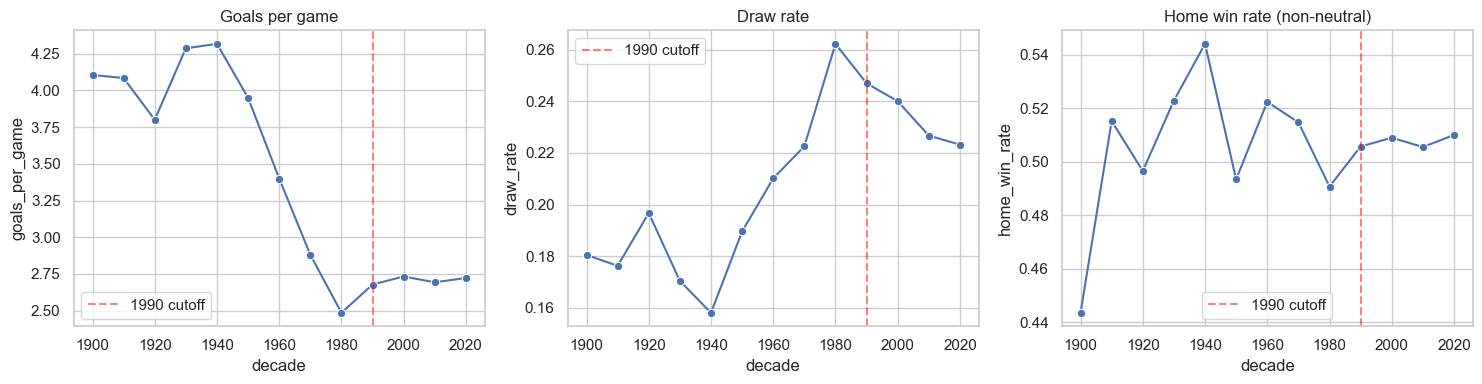

,home_win_rate,draw_rate,goals_per_game,n
decade,,,,
1900,0.444,0.180,4.105,133
1910,0.515,0.176,4.085,295
1920,0.497,0.197,3.801,727
1930,0.523,0.170,4.288,939
1940,0.544,0.158,4.318,658
1950,0.493,0.190,3.949,1303
1960,0.522,0.210,3.400,2232
1970,0.515,0.223,2.880,3015
1980,0.491,0.262,2.485,3741


In [3]:
nn = df[~df["neutral"]]
era = (nn.groupby("decade", observed=True)
         .agg(home_win_rate=("outcome", lambda s: (s == "home_win").mean()),
              draw_rate=("outcome", lambda s: (s == "draw").mean()),
              goals_per_game=("total_goals", "mean"),
              n=("outcome", "size"))
         .loc[1900:])  # pre-1900 has too few matches to be meaningful

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(
        axes, ["goals_per_game", "draw_rate", "home_win_rate"],
        ["Goals per game", "Draw rate", "Home win rate (non-neutral)"]):
    sns.lineplot(era, x="decade", y=col, marker="o", ax=ax)
    ax.axvline(1990, color="red", ls="--", alpha=0.5, label="1990 cutoff")
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

era.round(3)

**Findings:**
- **Goals per game** collapsed from ~4.3 (1930s–40s) to ~2.7 — tactics, fitness, and professionalism changed the game itself.
- **Draw rate** drifted from ~0.16 to a peak of 0.26 (1980s), settling at ~0.22–0.25.
- **Home win rate** is comparatively stable (~0.49–0.52) — home advantage is the most era-stable of the three.
- **Crucially, all three series flatten after 1990**: goals 2.68–2.73, draws 0.23–0.25, home wins ~0.51 per decade. The post-1990 era is close to stationary — strong empirical support for the 1990+ training window, while pre-1990 data still serves Elo warm-up (relative team strength transfers across eras even when base rates don't).

## 3. Dissolved-nations audit

Elo is a running computation keyed on team name. A renamed team restarts at the base rating — a discontinuity. We check which historical entities exist as separate names, and where the dataset has already merged.

In [4]:
watch = ["Soviet Union", "USSR", "Russia", "Yugoslavia", "Serbia",
         "Serbia and Montenegro", "Montenegro", "Czechoslovakia",
         "Czech Republic", "Czechia", "Slovakia", "Germany", "West Germany",
         "German DR", "East Germany", "Saarland"]

teams = pd.concat([
    df[["date", "home_team"]].rename(columns={"home_team": "team"}),
    df[["date", "away_team"]].rename(columns={"away_team": "team"})])

audit = (teams[teams["team"].isin(watch)]
         .groupby("team")["date"]
         .agg(matches="count", first="min", last="max"))
audit["first"], audit["last"] = audit["first"].dt.year, audit["last"].dt.year
audit.sort_values("first")

,matches,first,last
team,,,
Czechoslovakia,520,1903,1993
Germany,1031,1908,2026
Russia,748,1910,2026
Yugoslavia,483,1920,1992
Slovakia,367,1939,2026
Montenegro,170,1946,2026
Serbia,348,1950,2026
German DR,298,1952,1990
Saarland,9,1953,1956


**Findings:**
- Already merged by the dataset: West Germany → **Germany** (continuous 1908→); USSR → **Russia** (continuous 1910→).
- Separate entities with hard stops: **Czechoslovakia** (→1993), **Yugoslavia** (→1992), **German DR** (→1990), **Saarland** (9 matches, →1956).
- Successors starting fresh: **Czech Republic** (1994→), **Serbia** (entries from 1950, modern era continuous).


**Decisions (confirmed):**
- Czechoslovakia -> merge into **Czech Republic** (FIFA successor; avoids 1994 cold-start inside the training window). Slovakia cold-starts as a new team.
- Yugoslavia -> merge into **Serbia** (successor via FR Yugoslavia); drop the spurious 1950 Croatia-Serbia friendly. Croatia/Slovenia/etc. cold-start as new teams.
- German DR and Saarland -> **keep separate** (no successor restart; they end naturally and still inform opponents' warm-up Elo).

Implementation lives in `src/data/clean.py` (Phase 2), applied as a rename map before any Elo computation.
